# DCT Encoding / Blocking

In [2]:
%load_ext autoreload
%autoreload 2

import os
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt
from typing import Union, Tuple

from timm.layers import to_2tuple

import torch
import torchvision
import torch.nn as nn

from jutils import ims_to_grid
from jutils.nn import AutoencoderKL
from jutils import tensor2im, freeze

while not os.path.exists('ldm'):
    %cd ..
assert os.path.exists('ldm')

from processing.utils.hdf5_handler import DataHandler
from experiments.utils.utility import denorm_tensor


DEV = 'cuda:0'

/export/home/ra93jiz/miniconda3/envs/ldm-env-v2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/export/home/ra93jiz/dev/Img-IDM/notebooks
/export/home/ra93jiz/dev/Img-IDM


-----
### Utility Functions

In [6]:
def show_grid(img: torch.Tensor):
    ims = denorm_tensor(img.detach().cpu())
    
    grid = torchvision.utils.make_grid(ims, nrow=4, padding=0)
    grid = grid.permute(1, 2, 0).numpy()  # Convert to HWC format
    
    plt.figure(figsize=(5, 5))
    plt.imshow(grid)
    plt.axis('off')
    plt.show()
    
    
    
def show(img: torch.Tensor, save_to=None) -> None:
    img = img.clone().to(torch.float32)
    
    # Normalize the image to [0, 1]
    min, max = img.min(), img.max()
    img.clamp_(min=min, max=max)
    img.add_(-min).div_(max - min + 1e-5)
    
    # Convert to NumPy
    fig = plt.figure(figsize=(20, 8))
    plt.imshow(img.detach().cpu().permute(1, 2, 0).numpy(), interpolation='nearest')
    plt.xticks([])
    plt.yticks([])
    
    if save_to is not None:
        plt.imsave(save_to, img.detach().cpu().permute(1, 2, 0).numpy())
    plt.show()
    plt.close(fig)

--------
### Load Model

In [7]:
# SD-AE with 32x32 input
vae = AutoencoderKL(ckpt_path="checkpoints/sd_ae.ckpt")

[AutoencoderKL] Loading checkpoint from checkpoints/sd_ae.ckpt


------
### Load Data


[HDF5DataModule] Setting base directory to /export/home/ra93jiz/dev/Img-IDM/dataset/processed/needs-fix/imagenet256_data.hdf5
[HDF5LatentsDataset] Dataset size: 358531
[HDF5LatentsDataset] Dataset size: 358531
[HDF5LatentsDataset] Dataset size: 358531
[HDF5LatentsDataset] Dataset size: 358531
image      torch.Size([16, 3, 256, 256])
latent     torch.Size([16, 4, 32, 32])
label      torch.Size([16, 1])
Min images: -1.00, Max images: 1.01


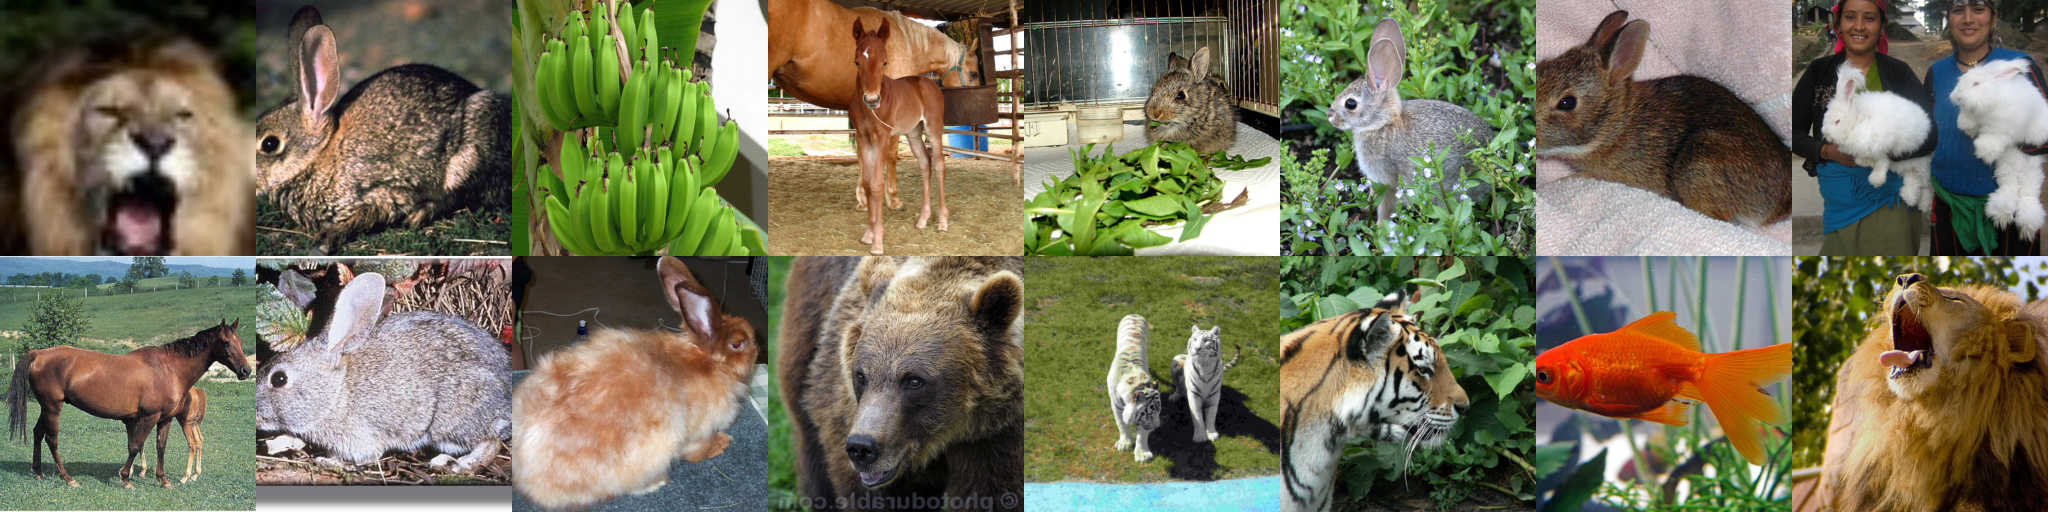

In [8]:
timestep = 0.5
data_dir = data_dir = './dataset/processed/needs-fix/imagenet256_data.hdf5'
class_labels=[
    0, 1, 154, 158, 250,
    236, 291, 292, 294, 
    296, 330, 332, 339, 
    340, 954, 957
    ]
batch_size = len(class_labels)
datahandler = DataHandler(data_dir)
data = datahandler.load_from_hdf5(data_dir, batch_size=batch_size, timestep=timestep)

for batch in data.train_dataloader():
    for k, v in batch.items():
        if isinstance(v, torch.Tensor) or isinstance(v, np.ndarray):
            print(f"{k:<10} {v.shape}")
        elif isinstance(v, list):
            print(f"{k:<10} [{v[0]}, ...]")
        else:
            print(f"{k:<10} {type(v)}")
    break

# Select single batch 
latents = batch['latent']
images = batch['image']
labels = batch['label']

print(f"Min images: {images.min():.2f}, Max images: {images.max():.2f}")

ims = tensor2im(images)
ims = ims_to_grid(ims, split=2, channel_last=True)
Image.fromarray(ims).show()

-----
### YCbCr Image Encoding / Blocking for JPEG Standard

/tmp/ipykernel_278159/3697456850.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  IYCbCr[:, 0, :, :] = 0.299 * R + 0.587 * G + 0.114 * B          # Y
/tmp/ipykernel_278159/3697456850.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  IYCbCr[:, 1, :, :] = -0.1687 * R - 0.3313 * G + 0.5 * B + 128   # Cb
/tmp/ipykernel_278159/3697456850.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implemen

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

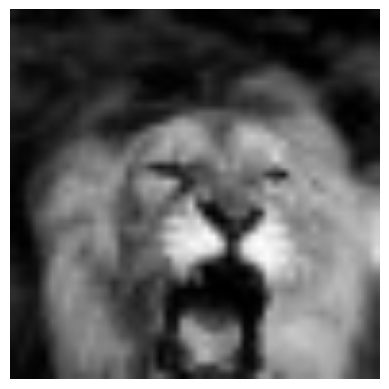

In [26]:
import skimage as ski

block_size = 8

# Image shape (B, 3, 256, 256)
R = images[:, 0, :, :]
G = images[:, 1, :, :]
B = images[:, 2, :, :]

# Y (Illuninance), Cb (Chrominance blue), Cr (Chrominance red)
IYCbCr = np.zeros(images.shape)
IYCbCr[:, 0, :, :] = 0.299 * R + 0.587 * G + 0.114 * B          # Y
IYCbCr[:, 1, :, :] = -0.1687 * R - 0.3313 * G + 0.5 * B + 128   # Cb
IYCbCr[:, 2, :, :] = 0.5 * R - 0.4187 * G - 0.0813 * B + 128    # Cr

# Visualize the Y channel
plt.imshow(IYCbCr[0, 0, :, :], cmap='gray')
plt.axis('off')

(32, 32, 8, 8)


(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

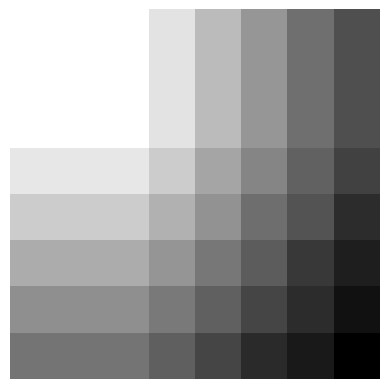

In [27]:
IYblock = ski.util.view_as_blocks(IYCbCr[0, 0, :, :], (block_size, block_size))
Cbblock = ski.util.view_as_blocks(IYCbCr[0, 1, :, :], (block_size, block_size))
Crblock = ski.util.view_as_blocks(IYCbCr[0, 2, :, :], (block_size, block_size))

# get row (32 at index 0) and column (32 at index 1) of a block
print(IYblock.shape)

# Visualize the Y channel
plt.imshow(IYblock[0, 0, :, :], cmap='gray')
plt.axis('off')

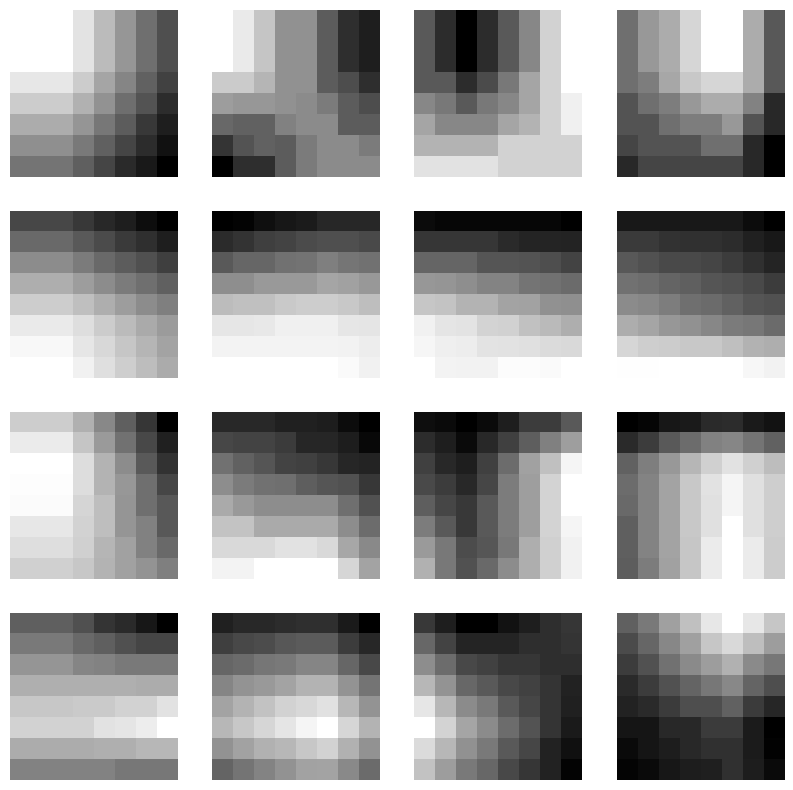

In [25]:
plt.figure(figsize=(10, 10))
k = 1
for i in range(4):
    for j in range(4):
        plt.subplot(4, 4, k)
        plt.imshow(IYblock[i, j, :, :], cmap='gray')
        plt.axis('off')
        k += 1
plt.show()

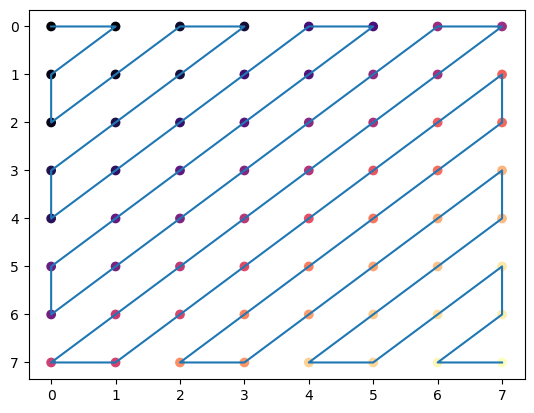

In [31]:
# Constructing DCT Basis in Zig-Zag Order
# Encode blocks to sign and cosine values
# https://github.com/ctraliedotcom/JPEGTutorial/blob/main/DCTConcept.ipynb

def get_zigzag_order(N):
    istart, jstart = 0, 0
    order = []
    for d in range(2*N-1): # 2*N -1 Diagonals
        # Loop through diagonal
        i = istart
        j = jstart
        diag = []
        while i >= 0 and j < N:
            diag.append([i, j])
            i -= 1
            j += 1
        if d%2 == 1:
            diag = reversed(diag)
        order += diag
        if istart == N-1:
            jstart += 1
        else:
            istart += 1
    return order
order = get_zigzag_order(8)
order = np.array(order)
plt.scatter(order[:, 1], order[:, 0], c=np.arange(order.shape[0]), cmap='magma')
plt.plot(order[:, 1], order[:, 0])
plt.gca().invert_yaxis()